# Cell Analysis 

## Concepts and work flow : 

Using the developed tools we will do the following for one cell : 
1. load data 
2. segment data and process number of blocks 
3. decide on KPIs to extract 
4. Extract KPIs for each cycle 
5. visualize KPIs for the cell


## Imports and Data preparation and processing 

In [1]:
import sys
import os
import yaml
import pandas as pd 


# Add src/ to sys.path so you can import batterydata
sys.path.append(os.path.abspath('../src'))

from batterydata.parsers.basytec_reader import BasyTecReader
from batterydata.pipeline.preprocessor import Preprocessor

In [2]:


with open('../local_config.yaml', 'r') as f:
    config = yaml.safe_load(f)
file_path = config['basytec_sample_file']


# Load data
reader = BasyTecReader(filepath=file_path, sample_id="demo")
result = reader.read()
df = result['data']




In [3]:
# Instantiate Preprocessor and process
preproc = Preprocessor(df, cell_capacity_ah=1.3)
seg, doe, blocks = preproc.process_with_blocks(min_block_len=4, max_block_len=4, min_repeats=2)
tables = preproc.export_tables()
segmented_df = tables["segmented_data"]
doe_table = tables["doe_table"]
metadata_table = tables["metadata"]

In [4]:
try:
    pd.testing.assert_frame_equal(segmented_df, seg)
    print("DataFrames are exactly equal")
except AssertionError as e:
    print("DataFrames differ:", e)



DataFrames are exactly equal


In [5]:
from typing import List, Dict

def pretty_print_blocks(blocks: List[Dict[str, object]]) -> None:
    """Print a readable summary of detected blocks.

    Parameters
    ----------
    blocks : list of dict
        Output from detect_repeating_blocks_with_steps() or find_repeating_blocks().
    """
    for b in blocks:
        step = b['start']
        if b['count'] > 1:
            print(f"Step {step}: {b['count']} x ({', '.join(b['block'])})")
        else:
            print(f"Step {step}: {', '.join(b['block'])}")


In [6]:
pretty_print_blocks(blocks)

Step 0: DIS_1.00_V3.0_noCV
Step 1: OCV_600
Step 2: 200 x (CH_1.00_V4.2_CV, OCV_10, DIS_1.00_V3.0_noCV, OCV_10)
Step 802: DIS_1.00_V3.0_CV
Step 803: OCV_10
Step 804: CH_0.05_V4.2_noCV
Step 805: OCV_10
Step 806: DIS_0.05_V3.0_CV
Step 807: 160 x (OCV_10, CH_1.00_V4.2_CV, OCV_10, DIS_1.00_V3.0_noCV)
Step 1447: OCV_10
Step 1448: CH_1.00_V3.8_CV
Step 1449: 35 x (CH_1.00_V4.2_CV, OCV_10, DIS_1.00_V3.0_noCV, OCV_10)
Step 1589: CH_1.00_V4.2_CV
Step 1590: OCV_10
Step 1591: DIS_1.00_V3.9_CV


This indicates that the cell had :
1. Discharge initial step 
2. Rest for 600 seconds
3. 200 x 
    1. charge CCCV
    2. rest 10 seconds
    3. Discharge CC 
    4. rest 10 seconds 
4. Discharge 
5. qOCV step : 
    1. Charge CCCV C/20
    2. rest 10 seconds 
    3. Discharge CC C/20


## Defining KPIs 



Lets define the following KPIs to be calculated for this test procedure. 

First of all for each cycle calculate 

<ol type='a'>
<li> charge capacity</li>
<li> discharge capcity </li>
<li> Energy charge </li>
<li> Energy discharge </li>
<li> Culombic Efficiency C/E % </li>
<li> Energy Efficiency E/E % </li>
<li> Capacity retention (Qi / Q1) </li>
<li> Total charge time </li>
<li> CV step duration</li>
<li> CC step duration </li>
<li> CV duration / total charge time </li>

</ol>


## KPI calculation using KPI engine 


In [7]:
# select a cycle : 
# from doe  teable, where block id = 2  
doe_cycle_df = doe[(doe['block_id']== 2 )]

# from segmented table select what was selected in deo table by step_number
raw_cycle_df = seg[(seg['step_number'].isin(doe_cycle_df['step_number'].tolist()))]

In [8]:
raw_cycle_df

,time_s,dataset_idx,step_time_s,set_time_s,line_idx,voltage_v,current_a,charge_ah,step_charge_ah,energy_wh,cycle_index,state_code,step_type,step_number,cc_cv
2325,2.318610e+03,2326,0.00451,2.318610e+03,6,3.169672,1.298755,-0.620380,0.000002,-2.282471,1,0,charge,4,CC
2326,2.319609e+03,2327,1.00335,2.319609e+03,6,3.188562,1.300026,-0.620019,0.000362,-2.281324,1,1,charge,4,CC
2327,2.320610e+03,2328,2.00413,2.320610e+03,6,3.199248,1.300008,-0.619658,0.000724,-2.280169,1,1,charge,4,CC
2328,2.321608e+03,2329,3.00282,2.321608e+03,6,3.208408,1.299999,-0.619297,0.001084,-2.279014,1,1,charge,4,CC
2329,2.322609e+03,2330,4.00382,2.322609e+03,6,3.216994,1.300017,-0.618936,0.001446,-2.277852,1,1,charge,4,CC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1446655,1.444588e+06,1446656,7.00345,1.444588e+06,9,3.031901,0.000000,-0.612063,0.000000,13.887679,200,1,OCV,1003,OCV
1446656,1.444589e+06,1446657,8.00360,1.444589e+06,9,3.033809,0.000000,-0.612063,0.000000,13.887679,200,1,OCV,1003,OCV
1446657,1.444590e+06,1446658,9.00361,1.444590e+06,9,3.035718,0.000000,-0.612063,0.000000,13.887679,200,1,OCV,1003,OCV
1446658,1.444591e+06,1446659,10.00000,1.444591e+06,9,3.037435,0.000000,-0.612063,0.000000,13.887679,200,2,OCV,1003,OCV


In [13]:
from batterydata.pipeline.kpi_engine import *

In [14]:
kpis = [
    QChargeAh(), QDischargeAh(), EChargeWh(), EDischargeWh(),
    CoulombicEfficiency(), EnergyEfficiency(), VChargeAvg(), VDischargeAvg(),
    ChargeTotalDurationSeconds(), ChargeCVDurationSeconds(),
    ChargeCVTimeRatio(), ChargeCVCapacityRatio(), CCVTotalMismatchPct(),
    QChargeAhCV(), QChargeAhCC(), QChargeAhByCCCV(),   # <- new
]

# Table over all cycles present in DOE (single-block assumed)
kpi_table = compute_multi_cycle_kpi_table(
    raw_df=seg,
    doe_df=doe,
    kpi_units=kpis,
    cycles=None,  # or pass a list like [1, 2, 3]
    block_col="block_id",
    cycle_col_candidates=("cycle_number", "cycle_index"),
    step_col="step_number",
)

# Add retentions
kpi_table = add_capacity_retention(kpi_table, discharge_col="Q_discharge_Ah", block_col="block_id")
kpi_table = add_energy_retention(kpi_table, energy_col="E_discharge_Wh", block_col="block_id")



In [15]:
kpi_table

,block_id,cycle_index,has_charge,has_discharge,is_partial_cycle,debug_stats,Q_charge_Ah,Q_discharge_Ah,E_charge_Wh,E_discharge_Wh,...,Charge_CV_duration_s,Charge_CV_time_ratio,Charge_CV_capacity_ratio,cccv_vs_total_mismatch_%,Q_charge_Ah_CV,Q_charge_Ah_CC,Q_charge_Ah_by_cccv,cycle_number,CapacityRetention_%,EnergyRetention_%
0,0,1,True,True,False,"{'charge': {'runs': 5, 'rows': 84069, 'pairs':...",6.230014,6.104346,24.218722,23.370426,...,1496.27009,0.017800,0.022791,0.030364,0.141946,6.086176,6.228122,1,100.000000,100.000000
1,2,2,True,True,False,"{'charge': {'runs': 3, 'rows': 11201, 'pairs':...",3.736435,3.734839,14.539943,14.285430,...,1132.68635,0.101190,0.027654,0.028984,0.103298,3.632054,3.735352,2,100.000000,100.000000
2,2,3,True,True,False,"{'charge': {'runs': 3, 'rows': 11199, 'pairs':...",3.736000,3.734647,14.537722,14.285115,...,1132.14606,0.101155,0.027638,0.029009,0.103225,3.631692,3.734917,3,99.994853,99.997794
3,2,4,True,True,False,"{'charge': {'runs': 3, 'rows': 11203, 'pairs':...",3.735853,3.734658,14.536870,14.285396,...,1134.17951,0.101310,0.027503,0.028995,0.102716,3.632054,3.734770,4,99.995133,99.999761
4,2,5,True,True,False,"{'charge': {'runs': 3, 'rows': 11199, 'pairs':...",3.735638,3.734470,14.535753,14.284924,...,1132.00805,0.101144,0.027544,0.028993,0.102863,3.631692,3.734555,5,99.990103,99.996455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2,196,True,True,False,"{'charge': {'runs': 1, 'rows': 3718, 'pairs': ...",1.244288,1.243956,4.840493,4.759106,...,362.28837,0.097513,0.026918,0.029041,0.033483,1.210444,1.243927,196,33.306806,33.314403
196,2,197,True,True,False,"{'charge': {'runs': 1, 'rows': 3724, 'pairs': ...",1.244361,1.244002,4.840807,4.759353,...,368.33121,0.098978,0.026974,0.029012,0.033555,1.210444,1.244000,197,33.308046,33.316133
197,2,198,True,True,False,"{'charge': {'runs': 1, 'rows': 3728, 'pairs': ...",1.244413,1.244023,4.841055,4.759365,...,372.68824,0.100032,0.027015,0.029034,0.033608,1.210444,1.244052,198,33.308613,33.316221
198,2,199,True,True,False,"{'charge': {'runs': 1, 'rows': 3722, 'pairs': ...",1.244369,1.243996,4.840816,4.759194,...,366.68765,0.098580,0.026981,0.029005,0.033564,1.210444,1.244008,199,33.307871,33.315020


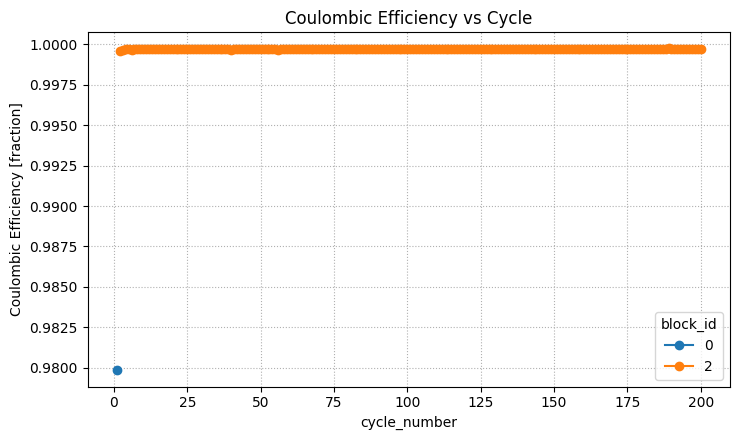

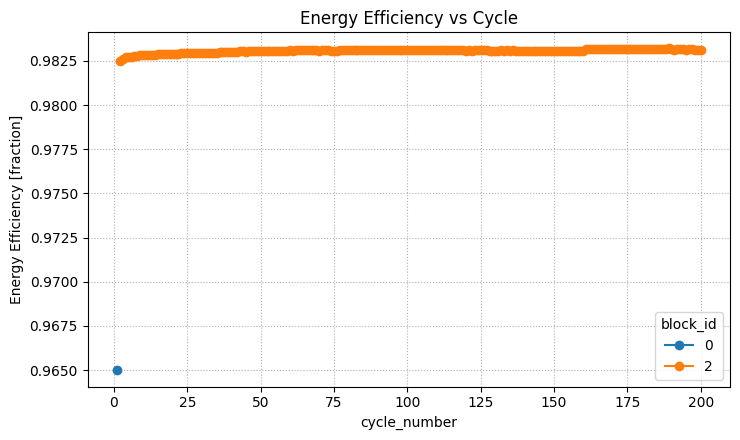

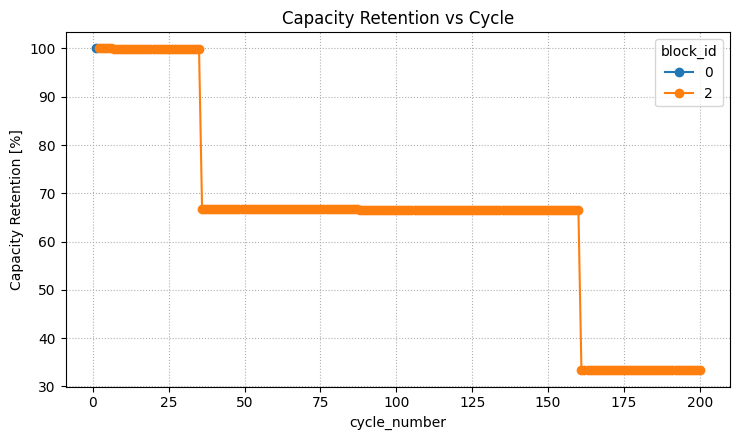

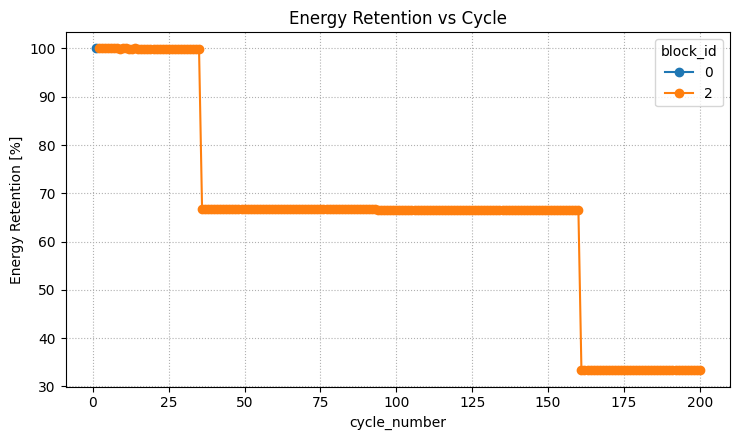

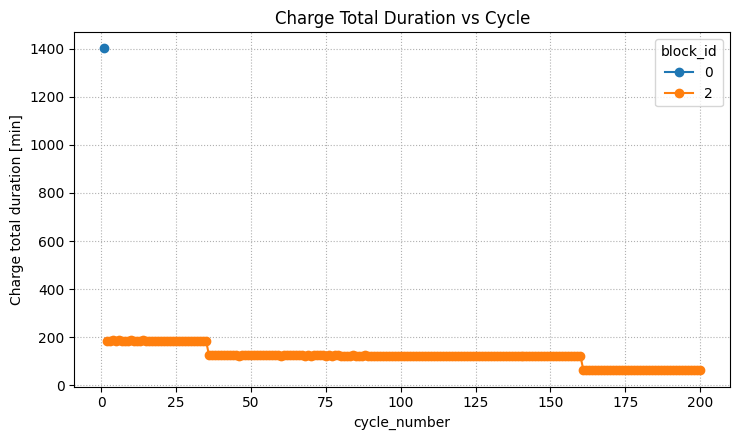

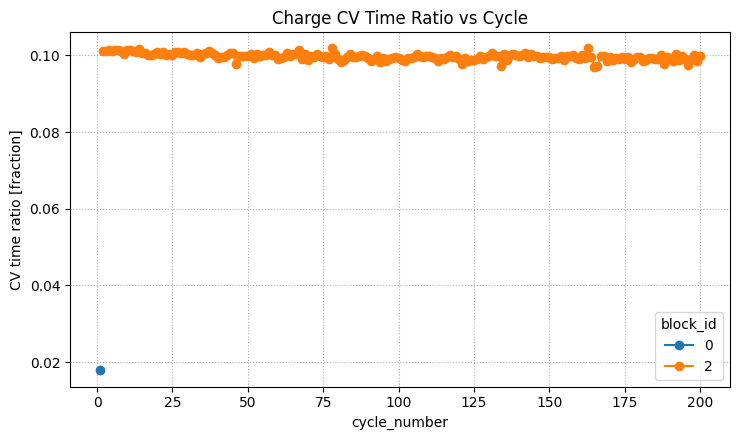

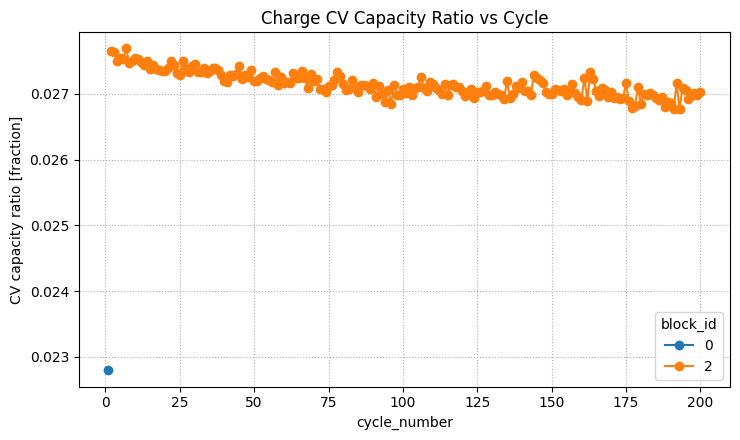

In [21]:
# plot some of the KPIs 
# plot the following vs. Cycle number : 
# coulombic efficiency 
# Energy Efficiency 
# capacity retention 
# Energy retention 

# Then we will analyze the Constant voltage step : 
# Charge total duration 
# CV time ratio 
# Charge CV time ratio 



# --- KPI plotting helpers (Matplotlib only; one chart per function) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _cycle_col(df: pd.DataFrame) -> str:
    """Auto-pick the cycle column."""
    for c in ("cycle_number", "cycle_index"):
        if c in df.columns:
            return c
    raise KeyError("No 'cycle_number' or 'cycle_index' in KPI table.")

def _iter_blocks(df: pd.DataFrame):
    """Yield (label, frame) per block, else single ('All', df)."""
    if "block_id" in df.columns:
        for b, g in df.groupby("block_id", sort=True):
            yield str(b), g
    else:
        yield "All", df

def _line_plot(df: pd.DataFrame, x: str, y: str, title: str, ylabel: str, legend_title="block_id"):
    """Generic line plot with basic cleaning and sorting."""
    if y not in df.columns:
        raise KeyError(f"'{y}' not found in KPI table.")
    if x not in df.columns:
        raise KeyError(f"'{x}' not found in KPI table.")

    plt.figure(figsize=(7.5, 4.5))
    any_line = False
    for label, g in _iter_blocks(df):
        xv = pd.to_numeric(g[x], errors="coerce")
        yv = pd.to_numeric(g[y], errors="coerce")
        m = np.isfinite(xv) & np.isfinite(yv)
        if not m.any():
            continue
        xv = xv[m]
        yv = yv[m]
        order = np.argsort(xv.values)
        plt.plot(xv.iloc[order], yv.iloc[order], marker="o", linewidth=1.5, label=label)
        any_line = True

    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(ylabel)
    plt.grid(True, which="both", linestyle=":", linewidth=0.8)
    if any_line and "block_id" in df.columns:
        plt.legend(title=legend_title)
    plt.tight_layout()
    plt.show()

# =======================
# 1) Efficiency & Retention vs Cycle
# =======================

def plot_coulombic_efficiency(kpi_table: pd.DataFrame) -> None:
    x = _cycle_col(kpi_table)
    _line_plot(kpi_table, x, "CoulombicEfficiency",
               title="Coulombic Efficiency vs Cycle",
               ylabel="Coulombic Efficiency [fraction]")

def plot_energy_efficiency(kpi_table: pd.DataFrame) -> None:
    x = _cycle_col(kpi_table)
    _line_plot(kpi_table, x, "EnergyEfficiency",
               title="Energy Efficiency vs Cycle",
               ylabel="Energy Efficiency [fraction]")

def plot_capacity_retention(kpi_table: pd.DataFrame) -> None:
    x = _cycle_col(kpi_table)
    _line_plot(kpi_table, x, "CapacityRetention_%",
               title="Capacity Retention vs Cycle",
               ylabel="Capacity Retention [%]")

def plot_energy_retention(kpi_table: pd.DataFrame) -> None:
    x = _cycle_col(kpi_table)
    _line_plot(kpi_table, x, "EnergyRetention_%",
               title="Energy Retention vs Cycle",
               ylabel="Energy Retention [%]")

# =======================
# 2) CV step analysis vs Cycle
# =======================

def plot_charge_total_duration(kpi_table: pd.DataFrame, unit: str = "min") -> None:
    """
    Plot Charge_total_duration vs cycle.
    unit: 's' or 'min' (default).
    """
    if unit not in {"s", "min"}:
        raise ValueError("unit must be 's' or 'min'")
    base = "Charge_total_duration_s"
    if base not in kpi_table.columns:
        raise KeyError(f"'{base}' not found in KPI table.")

    df = kpi_table.copy()
    ycol = base
    ylabel = "Charge total duration [s]"
    if unit == "min":
        df["Charge_total_duration_min"] = pd.to_numeric(df[base], errors="coerce") / 60.0
        ycol = "Charge_total_duration_min"
        ylabel = "Charge total duration [min]"

    x = _cycle_col(df)
    _line_plot(df, x, ycol, title="Charge Total Duration vs Cycle", ylabel=ylabel)

def plot_cv_time_ratio(kpi_table: pd.DataFrame) -> None:
    x = _cycle_col(kpi_table)
    _line_plot(kpi_table, x, "Charge_CV_time_ratio",
               title="Charge CV Time Ratio vs Cycle",
               ylabel="CV time ratio [fraction]")

def plot_cv_capacity_ratio(kpi_table: pd.DataFrame) -> None:
    x = _cycle_col(kpi_table)
    _line_plot(kpi_table, x, "Charge_CV_capacity_ratio",
               title="Charge CV Capacity Ratio vs Cycle",
               ylabel="CV capacity ratio [fraction]")

# -----------------------

plot_coulombic_efficiency(kpi_table)
plot_energy_efficiency(kpi_table)
plot_capacity_retention(kpi_table)
plot_energy_retention(kpi_table)
plot_charge_total_duration(kpi_table, unit="min")
plot_cv_time_ratio(kpi_table)
plot_cv_capacity_ratio(kpi_table)
# -----------------------




In [23]:
seg.head()

,time_s,dataset_idx,step_time_s,set_time_s,line_idx,voltage_v,current_a,charge_ah,step_charge_ah,energy_wh,cycle_index,state_code,step_type,step_number,cc_cv
0,0.00000,1,0.00000,0.00000,2,3.832572,-0.000541,-3.552998e-08,-3.552998e-08,-1.361712e-07,1,3,OCV,1,OCV
1,0.00338,2,0.00338,0.00338,2,3.826466,-1.298575,-1.254026e-06,-1.254026e-06,-4.798706e-06,1,0,discharge,2,CC
2,1.00237,3,1.00237,1.00237,2,3.820360,-1.299990,-3.620021e-04,-3.620021e-04,-1.383510e-03,1,1,discharge,2,CC
3,2.00182,4,2.00182,2.00182,2,3.818451,-1.300017,-7.229127e-04,-7.229127e-04,-2.761937e-03,1,1,discharge,2,CC
4,3.00259,5,3.00259,3.00259,2,3.816925,-1.299999,-1.084302e-03,-1.084302e-03,-4.141601e-03,1,1,discharge,2,CC


/tmp/ipykernel_462071/235097328.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  charge_curve['time_s'] = charge_curve['time_s'] - charge_curve['time_s'].min()
/tmp/ipykernel_462071/235097328.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  charge_curve['time_s'] = charge_curve['time_s'] - charge_curve['time_s'].min()
/tmp/ipykernel_462071/235097328.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inste

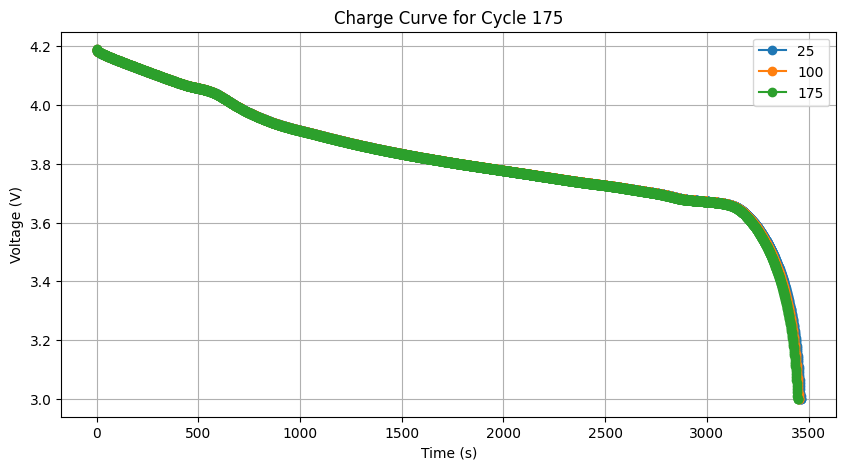

In [28]:
# plot charge curve and discharge curve from raw of the following cycle :
# from doe  table , where block id = 2 and cycle number are 25 , 100 , 175 
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
cycle_numbers = [25, 100, 175]
for cycle_number in cycle_numbers:
    # we need to filter the doe table first for block id and cycle number , 
    # after that we can filter the raw_cycle_df using the step_number from doe table
    doe_cycle_df = doe[(doe['block_id'] == 2) & (doe['cycle_number'] == cycle_number)]
    cycle_df = seg[seg['step_number'].isin(doe_cycle_df['step_number'].tolist())]
    
    # plot the charge curve first for each cycle number : 
    charge_curve = cycle_df[cycle_df['step_type'] == 'discharge']
    # set the time as relative time in seconds
    # need to minimize the whole time column from the first time value
    charge_curve['time_s'] = charge_curve['time_s'] - charge_curve['time_s'].min()
    
    plt.plot(charge_curve['time_s'], charge_curve['voltage_v'], label=cycle_number, marker='o')
    plt.title(f'Charge Curve for Cycle {cycle_number}')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (V)')
    plt.grid(True)
    plt.legend()
plt.show()  
